В этом домашнем задании вам предстоит с помощью Pandas ответить на несколько вопросов об этом [датасете](https://archive.ics.uci.edu/ml/datasets/Adult). Все ответы вам предстоит отправить в этой [форме](https://forms.gle/qfVth9BygS4AVJZ47)

Чтобы начать надо сохранить этот ноутбук себе на диск (File - Save a copy in Drive) или скачать (File - Download), если вы делаете у себя локально.

Скачать нужный датасет можно [тут](https://disk.yandex.ru/d/6WlIXR-y_PObLg)

Эта домашняя работа легкая и покрывает лишь некоторую базу, очень советую пройтись по доп.материалам и посмотреть на различные крутые штуки, которые может делать Pandas, Matplotlib или Seaborn. Особенно если вы хотите заниматься анализом данных намного серьезнее.

Мягкий дедлайн: 31 октября 23:59 \
Жесткий дедлайн: 7 ноября 23:59

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (18, 10)

**Задание 0: Прочитайте скачанный датасет и выведите его**

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df = pd.read_csv('/adult_data.csv')

**Задание 1: Найдите количество мужчин и количество женщин в датасете**

In [ ]:
male_count = (df.sex == 'Male').sum()
female_count = (df.sex == 'Female').sum()
print(f"Мужчин: {male_count}")
print(f"Женщин: {female_count}")

Мужчин: 21790
Женщин: 10771


**Задание 2: Найдите средний возраст мужчин**

In [ ]:
average_age_men = df[df['sex'] == 'Male']['age'].mean()
print(f"Средний возраст мужчин: {average_age_men:.2f} лет")

Средний возраст мужчин: 39.43 лет


**Задание 3: Найдите процент людей, которые являются гражданами Тайваня (Taiwan)**

In [ ]:
total_people = len(df)
taiwan_people = len(df[df['native-country'] == 'Taiwan'])
percentage = (taiwan_people / total_people) * 100

print(f"Процент людей из Тайваня: {percentage:.2f}%")
print(f"Количество людей из Тайваня: {taiwan_people} из {total_people}")

Процент людей из Тайваня: 0.16%
Количество людей из Тайваня: 51 из 32561


**Задание 4: Найдите среднее значение возраста для людей, которые зарабатывают >50K**

In [ ]:
average_age_high_earners = df[df['salary'] == '>50K']['age'].mean()
print(f"Средний возраст людей с зарплатой >50K: {average_age_high_earners:.2f} лет")

Средний возраст людей с зарплатой >50K: 44.25 лет


**Задание 5: Найдите стандартное отклонение возраста для людей, которые зарабатывают >50K**

In [ ]:
std_age_high_earners = df[df['salary'] == '>50K']['age'].std()
print(f"Стандартное отклонение возраста людей с зарплатой >50K: {std_age_high_earners:.2f} лет")

Стандартное отклонение возраста людей с зарплатой >50K: 10.52 лет


**Задание 6: Проверьте, правда ли что все люди, которые зарабытвают >50K, имеют образование Bachelors+**

In [ ]:
high_earners = df[df['salary'] == '>50K']
bachelors_plus = ['Bachelors', 'Masters', 'Doctorate', 'Prof-school']
all_have_bachelors_plus = high_earners['education'].isin(bachelors_plus).all()
below_bachelors_count = len(high_earners[~high_earners['education'].isin(bachelors_plus)])
if all_have_bachelors_plus:
    print("Правда: все люди с зарплатой >50K имеют образование Bachelors или выше")
else:
    print(f"Неправда: {below_bachelors_count} человек(а) с зарплатой >50K имеют образование ниже Bachelors")
    below_bachelors_education = high_earners[~high_earners['education'].isin(bachelors_plus)]['education'].value_counts()
    print("Уровни образования у высокооплачиваемых с образованием ниже Bachelors:")
    print(below_bachelors_education)

Неправда: 3932 человек(а) с зарплатой >50K имеют образование ниже Bachelors
Уровни образования у высокооплачиваемых с образованием ниже Bachelors:
education
HS-grad         1675
Some-college    1387
Assoc-voc        361
Assoc-acdm       265
10th              62
11th              60
7th-8th           40
12th              33
9th               27
5th-6th           16
1st-4th            6
Name: count, dtype: int64


**Задание 7: Сколько человек, работающих 40 часов и являющихся гражданами США (United-States), зарабатывают <=50K**

In [ ]:
filtered_data = df[(df['hours-per-week'] == 40) & (df['native-country'] == 'United-States') & (df['salary'] == '<=50K')]
count = len(filtered_data)
print(f"Количество человек, работающих 40 часов, являющихся гражданами США и зарабатывающих <=50K: {count}")

Количество человек, работающих 40 часов, являющихся гражданами США и зарабатывающих <=50K: 10493


**Задание 8: Теперь чуть сложнее. Давайте найдем максимальное количество часов в неделю (hours-per-week), а потом посмотрим, сколько человек работают столько времени в неделю и зарабатывают <=50K**

In [ ]:
max_hours = df['hours-per-week'].max()
print(f"Максимальное количество рабочих часов в неделю: {max_hours}")
filtered_people = df[(df['hours-per-week'] == max_hours) & (df['salary'] == '<=50K')]
count = len(filtered_people)
print(f"Количество человек, работающих {max_hours} часов в неделю и зарабатывающих <=50K: {count}")

Максимальное количество рабочих часов в неделю: 99
Количество человек, работающих 99 часов в неделю и зарабатывающих <=50K: 60


**Задание 9: В этом задании вам предстоит построить ваш первый график. Ответьте на вопрос: людей с каким образованием больше всего представленно в датасете? \
P.S Использовать можно matplotlib, seaborn, plotly**

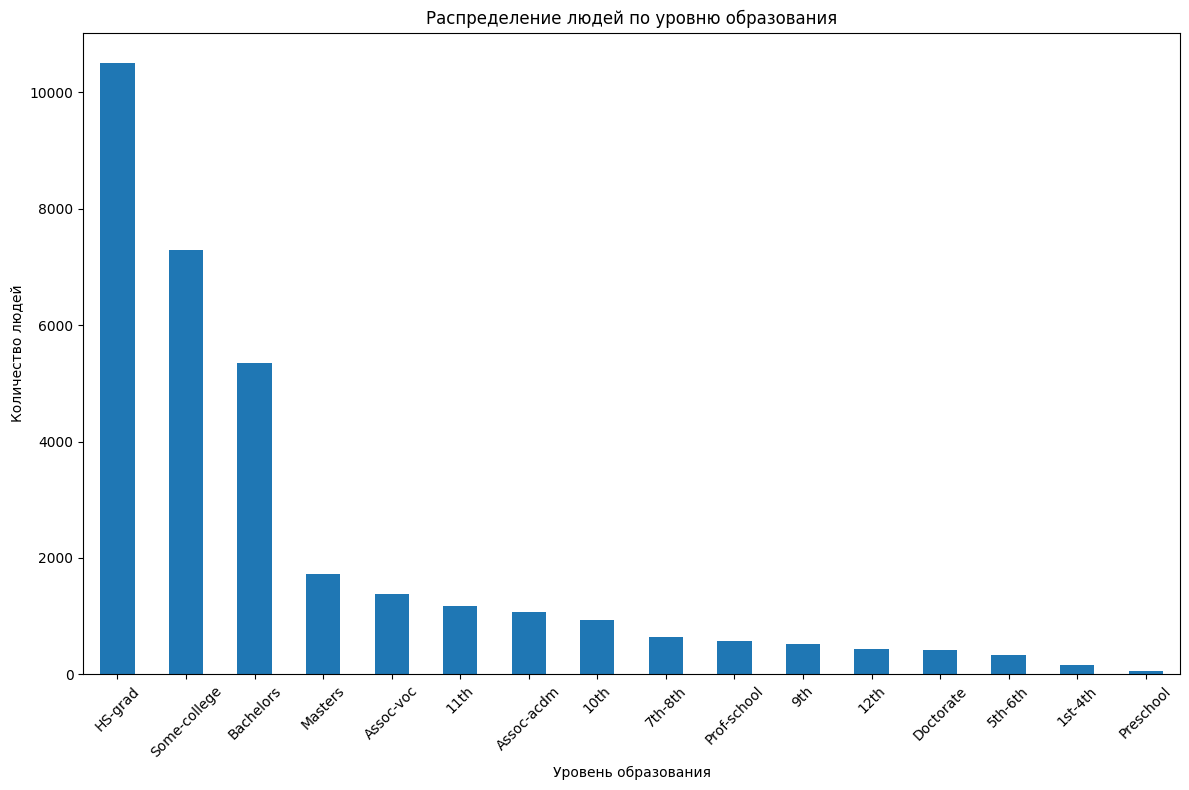

In [ ]:
education_counts = df['education'].value_counts()
plt.figure(figsize=(12, 8))
education_counts.plot(kind='bar')
plt.title('Распределение людей по уровню образования')
plt.xlabel('Уровень образования')
plt.ylabel('Количество людей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Задание 10: А теперь давайте посмотрим на распределение возрастов. Сколько возрастных отрезков имеют больше 1600 значений? (Одним "отрезков" является один столбец при стандартных настройках seaborn/matplotlib)
P.S. Необязательное задание, хотя лучше сделать, если собираетесь сдавать до мягкого, я хоты бы посмотрю**

Количество возрастных отрезков с более чем 1600 значениями: 4
Общее количество возрастных отрезков: 59
Максимальное количество значений в одном отрезке: 1703
Минимальное количество значений в одном отрезке: 1


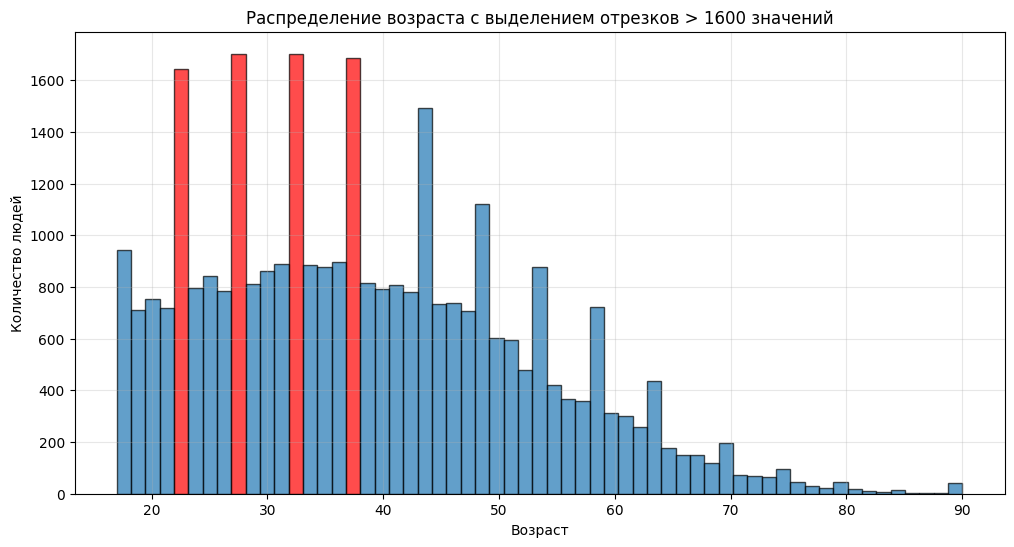

In [ ]:
counts, bins, patches = plt.hist(df['age'], bins='auto', edgecolor='black')

# Закроем график, так как он нам не нужен для отображения
plt.close()

# Посчитаем, сколько бинов имеют более 1600 значений
bins_over_1600 = np.sum(counts > 1600)

print(f"Количество возрастных отрезков с более чем 1600 значениями: {bins_over_1600}")
print(f"Общее количество возрастных отрезков: {len(counts)}")
print(f"Максимальное количество значений в одном отрезке: {max(counts):.0f}")
print(f"Минимальное количество значений в одном отрезке: {min(counts):.0f}")

# Дополнительно: визуализируем распределение с выделением отрезков > 1600
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(df['age'], bins='auto', edgecolor='black', alpha=0.7)

# Подсветим отрезки с более чем 1600 значениями
for i in range(len(patches)):
    if counts[i] > 1600:
        patches[i].set_facecolor('red')

plt.title('Распределение возраста с выделением отрезков > 1600 значений')
plt.xlabel('Возраст')
plt.ylabel('Количество людей')
plt.grid(True, alpha=0.3)
plt.show()